## 1. Autoencoder Optuna + Stochastic + Regularization + Dropout + Early Stopping (Private Score)

C:\Users\jarvis\AppData\Local\Temp\ipykernel_5016\656460183.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_outliers = outlier_rows.groupby("lettr").apply(lambda x: x.sample(n=min(len(x), rows_per_class), random_state=42)).reset_index(drop=True)
C:\Users\jarvis\AppData\Local\Temp\ipykernel_5016\656460183.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  extra_rows = remaining_rows.groupby("

Is using: cuda
✅ Outlier validation sample shape: (86, 17)
lettr
A    5
C    5
L    5
H    5
V    5
T    5
F    4
D    4
J    4
M    4
I    4
G    4
P    4
O    4
R    4
Q    4
S    4
U    4
W    4
Y    4
Name: count, dtype: int64
🔁 Training with seed 42


⏹️ Early stopped at epoch 41
🔁 Training with seed 52


⏹️ Early stopped at epoch 93
🔁 Training with seed 62


⏹️ Early stopped at epoch 98
🔁 Training with seed 72


⏹️ Early stopped at epoch 61


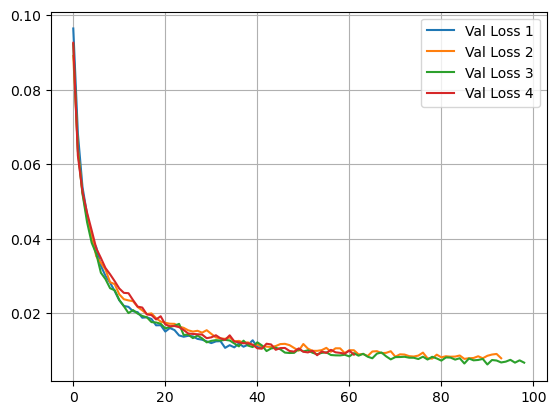

Best AUC score = 0.9133054645426127


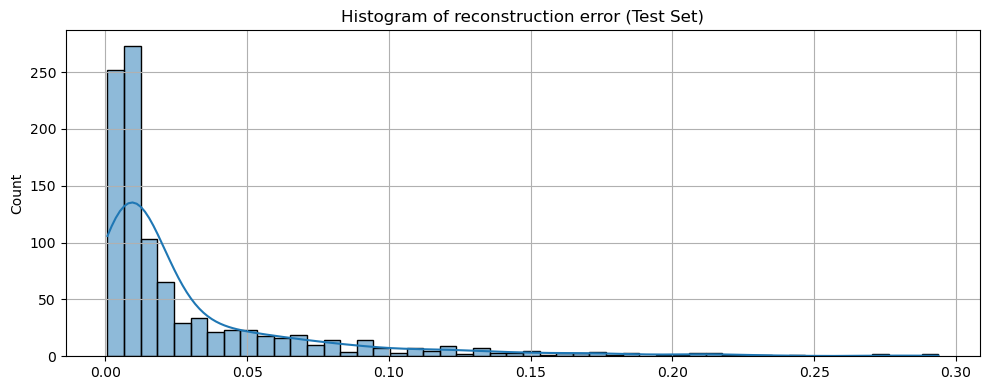

✅ Saved prediction to submission_best_seed_pytorch.csv


In [58]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import seaborn as sns

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Is using:", device)

# build the validation set
val = None
inliers = ['B', 'E', 'K', 'N', 'X', 'Z']
entire_df = pd.read_csv('entire_excluded_training.csv')
inlier_rows = entire_df[entire_df["lettr"].isin(inliers)]
outlier_rows = entire_df[~entire_df["lettr"].isin(inliers)]

# Get balanced outliers
# Tính số dòng mỗi nhãn cần lấy (chia đều)
unique_classes = outlier_rows["lettr"].unique()
n_classes = len(unique_classes)
rows_per_class = 86 // n_classes
remainder = 86 % n_classes  # còn dư để phân phối sau
# Lấy đều mỗi lớp
balanced_outliers = outlier_rows.groupby("lettr").apply(lambda x: x.sample(n=min(len(x), rows_per_class), random_state=42)).reset_index(drop=True)

# Nếu còn dư (ví dụ 86 không chia hết), lấy thêm từ một số lớp
if remainder > 0:
    additional = outlier_rows[~outlier_rows["lettr"].isin(balanced_outliers["lettr"])]  # chưa dùng lớp nào
    remaining_rows = outlier_rows[~outlier_rows.index.isin(balanced_outliers.index)]
    extra_rows = remaining_rows.groupby("lettr", group_keys=False).apply(lambda x: x.sample(1, random_state=42)).sample(n=remainder, random_state=42)
    balanced_outliers = pd.concat([balanced_outliers, extra_rows], ignore_index=True)

# Kết quả: đúng 86 dòng, cân bằng
print(f"✅ Outlier validation sample shape: {balanced_outliers.shape}")
print(balanced_outliers["lettr"].value_counts())

# Choose 
val_df = pd.DataFrame(np.concatenate([inlier_rows.values, balanced_outliers.values]), columns=entire_df.columns)
val_shuffled_df = val_df.sample(frac=1, random_state = 42).reset_index(drop=True)
y_val = val_shuffled_df["lettr"].apply(lambda x:0 if x in inliers else 1).values
X_val_full = val_shuffled_df.drop(columns=["lettr"]).apply(pd.to_numeric, errors = 'coerce').values

# Data preprocessing
train_df = pd.read_csv('training.csv')
test_df = pd.read_csv('test_X.csv')
entire_df = pd.read_csv('entire_excluded_training.csv') # so the validation set is very big.
X_train_full = train_df.drop(columns=["lettr"]).values
X_test_full = test_df.values
X_take_full = entire_df.drop(columns=["lettr"]).values
y_take = entire_df["lettr"].apply(lambda x:0 if x in inliers else 1).values

# Scale with same train params
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)
X_val_scaled = scaler.transform(X_val_full)
X_take_scaled = scaler.transform(X_take_full)

# Choose the validation mode: 0 ~ 0.1 trainset / 1 ~ 100% entireset
VAL_MODE = 1
assert VAL_MODE in [0, 1], "VAL_MODE must be 0 or 1"
# Make y_val by entire dataset a.k.a UCI letter recognition dataset_
if VAL_MODE == 0:
    X_train_np, X_val_np = train_test_split(X_train_scaled, test_size=0.1, random_state=42)
else:
    X_train_np = X_train_scaled
    X_val_np = X_val_scaled

# Convert to pytorch tensor
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_np, dtype=torch.float32)
X_take_tensor = torch.tensor(X_take_scaled, dtype=torch.float32)

# Set configuration
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=batch_size)
take_loader = DataLoader(TensorDataset(X_take_tensor), batch_size=batch_size)
huber_loss_fn = torch.nn.SmoothL1Loss(beta=1.0)

class AE(nn.Module):
    def __init__(self, input_dim):
        super(AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128), # flag
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(64),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Linear(128, input_dim)
        )
        
    def forward(self, X):
        encoded = self.encoder(X)
        decoder = self.decoder(encoded)
        return decoder

def train_model(model, train_loader, val_loader, epochs=100, patience=8, lr=1e-3, device='cuda'): # flag
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) 
    best_loss = float('inf')
    no_improve = 0
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for x in train_loop:
            x = x[0].to(device)
            optimizer.zero_grad()
            recon = model(x)
            loss = huber_loss_fn(recon, x)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            train_loop.set_postfix(loss=loss.item())  # ✅ cập nhật loss trên progress bar
            
        train_losses.append(running_loss / len(train_loader))
        
        # validation loss
        model.eval()
        val_loss = 0
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
        with torch.no_grad():
            for x in val_loop:
                x = x[0].to(device)
                recon = model(x)
                loss = huber_loss_fn(recon, x)
                val_loss += loss.item()
                val_loop.set_postfix(loss=loss.item())
                
        val_losses.append(val_loss / len(val_loader))
        
        # Early stopping
        if val_losses[-1] < best_loss:
            best_loss = val_losses[-1]
            best_model_state = model.state_dict()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"⏹️ Early stopped at epoch {epoch}")
                break
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses

# train multiple models
input_dim = X_train_tensor.shape[1]
seeds = [42, 52, 62, 72]
all_errors = []
val_min_losses = []
all_val_losses = []
best_model_state = None
best_model_auc = -9999
best_seed = None

for seed in seeds:
    random.seed(seed)
    print(f"🔁 Training with seed {seed}")
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = AE(input_dim).to('cuda')
    model, train_losses, val_loss = train_model(
        model,
        train_loader,
        val_loader
    )
    
    # Predict testset
    val_min_losses.append(min(val_loss))
    all_val_losses.append(val_loss)
    
    # test by validation set to choose the best seed
    model.eval()
    rcts = []
    with torch.no_grad():
        for x in take_loader:
            x = x[0].to("cuda")
            recon = model(x)
            mse = F.mse_loss(recon, x, reduction= 'none').mean(dim=1)
            rcts.extend(mse.cpu().numpy().tolist())
    np_rcts = np.array(rcts)
    temp_outlier_scores = RobustScaler().fit_transform(np_rcts.reshape(-1,1)).flatten()
    auc = roc_auc_score(y_take, temp_outlier_scores)
    if best_model_auc < auc:
        best_model_auc = auc
        best_model_state = model.state_dict()
        best_seed = seed

for i in range(len(seeds)):
    plt.plot(all_val_losses[i], label=f"Val Loss {i+1}")
plt.legend()
plt.grid(True)
plt.show()

# Load best model params
best_model = AE(input_dim).to(device)
best_model.load_state_dict(best_model_state)
best_model.eval()

print(f"Best AUC score = {best_model_auc}")

# Predict reconstruction error on test set
reconstructions = []
with torch.no_grad():
    for x in test_loader:
        x = x[0].to(device)
        recon = best_model(x)
        mse = F.mse_loss(recon, x, reduction='none').mean(dim=1)
        reconstructions.extend(mse.cpu().numpy().tolist())

# Scale scores using RobustScaler
outlier_scores = RobustScaler().fit_transform(np.array(reconstructions).reshape(-1, 1)).flatten()

# Plot histogram
plt.figure(figsize=(10, 4))
sns.histplot(reconstructions, bins=50, kde=True)
plt.title("Histogram of reconstruction error (Test Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Save to CSV
submission = pd.DataFrame({
    'id': np.arange(len(outlier_scores)),
    'outliers': outlier_scores
})
submission.to_csv('submission_best_seed_pytorch.csv', index=False, float_format='%.9f')
print("✅ Saved prediction to submission_best_seed_pytorch.csv")


In [59]:
# Get AUC of validation set
# Predict reconstruction error on test set
reconstructions = []
with torch.no_grad():
    for x in val_loader:
        x = x[0].to(device)
        recon = best_model(x)
        mse = F.mse_loss(recon, x, reduction='none').mean(dim=1)
        reconstructions.extend(mse.cpu().numpy().tolist())

# Scale scores using RobustScaler
outlier_scores = RobustScaler().fit_transform(np.array(reconstructions).reshape(-1, 1)).flatten()
print(f"AUC score = {roc_auc_score(y_val, outlier_scores)}")

AUC score = 0.8864712435593929


## 2. SVM + Optuna (Private Score)

## 3. SVM for Public Score